<a href="https://colab.research.google.com/github/Ebratul/Python/blob/main/HomeWork/HousePriceANN(Update).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
!pip install opendatasets

In [4]:
import opendatasets as od

In [5]:
od.download('https://www.kaggle.com/competitions/house-prices-advanced-regression-techniques/data?select=train.csv')

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: g65ashaharier21031
Your Kaggle Key: ··········


100%|██████████| 199k/199k [00:00<00:00, 383MB/s]


Extracting archive ./house-prices-advanced-regression-techniques/house-prices-advanced-regression-techniques.zip to ./house-prices-advanced-regression-techniques


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.preprocessing import LabelEncoder

In [7]:
df_test=pd.read_csv('/content/house-prices-advanced-regression-techniques/test.csv')
df_train=pd.read_csv("/content/house-prices-advanced-regression-techniques/train.csv")
print("train_shape: ",df_train.shape)
print("test_shape: ",df_test.shape)

train_shape:  (1460, 81)
test_shape:  (1459, 80)


In [8]:
pd.set_option('display.max_columns', None)
df_train.head(3)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500


In [9]:
df_train.isnull().sum().sort_values(ascending=False).head(10)

,0
PoolQC,1453
MiscFeature,1406
Alley,1369
Fence,1179
MasVnrType,872
FireplaceQu,690
LotFrontage,259
GarageQual,81
GarageFinish,81
GarageType,81


In [10]:
df_train.duplicated().sum()

np.int64(0)

In [11]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [12]:
df_train.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,TotRmsAbvGrd,Fireplaces,GarageYrBlt,GarageCars,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1379.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,46.549315,567.240411,1057.429452,1162.626712,346.992466,5.844521,1515.463699,0.425342,0.057534,1.565068,0.382877,2.866438,1.046575,6.517808,0.613014,1978.506164,1.767123,472.980137,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,161.319273,441.866955,438.705324,386.587738,436.528436,48.623081,525.480383,0.518911,0.238753,0.550916,0.502885,0.815778,0.220338,1.625393,0.644666,24.689725,0.747315,213.804841,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,0.000000,0.000000,0.000000,334.000000,0.000000,0.000000,334.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,0.000000,1900.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,0.000000,223.000000,795.750000,882.000000,0.000000,0.000000,1129.500000,0.000000,0.000000,1.000000,0.000000,2.000000,1.000000,5.000000,0.000000,1961.000000,1.000000,334.500000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,0.000000,477.500000,991.500000,1087.000000,0.000000,0.000000,1464.000000,0.000000,0.000000,2.000000,0.000000,3.000000,1.000000,6.000000,1.000000,1980.000000,2.000000,480.000000,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,0.000000,808.000000,1298.250000,1391.250000,728.000000,0.000000,1776.750000,1.000000,0.000000,2.000000,1.000000,3.000000,1.000000,7.000000,1.000000,2002.000000,2.000000,576.000000,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,1474.000000,2336.000000,6110.000000,4692.000000,2065.000000,572.000000,5642.000000,3.000000,2.000000,3.000000,2.000000,8.000000,3.000000,14.000000,3.000000,2010.000000,4.000000,1418.000000,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


In [13]:
missing=df_train.isnull().sum()
missing=missing[missing>0].sort_values(ascending=False)
missing.head(5)

,0
PoolQC,1453
MiscFeature,1406
Alley,1369
Fence,1179
MasVnrType,872


In [14]:
for df in [df_train, df_test]:
    for col in df.columns:
        if df[col].dtype.name == 'category' or df[col].dtype == 'object':
            df[col].fillna(df[col].mode()[0], inplace=True)
        else:
            df[col].fillna(df[col].median(), inplace=True)

/tmp/ipython-input-2769437982.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)
/tmp/ipython-input-2769437982.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try usin

In [15]:
df_train.isnull().sum().sum()

np.int64(0)

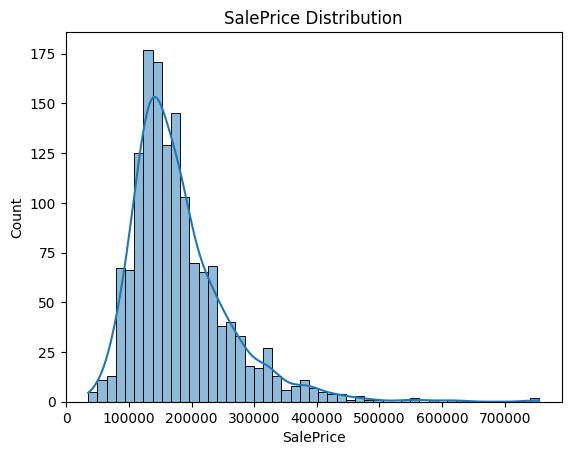

In [16]:
sns.histplot(df_train['SalePrice'], kde=True)
plt.title("SalePrice Distribution")
plt.show()

In [17]:
train = df_train.copy()
test = df_test.copy()

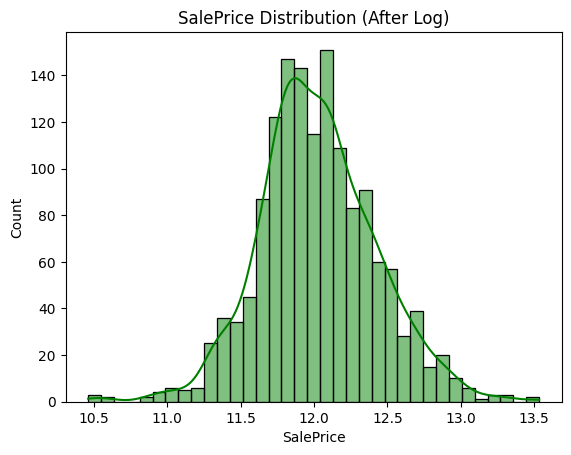

In [18]:
train["SalePrice"] = np.log(train["SalePrice"])

sns.histplot(train['SalePrice'], kde=True, color="green")
plt.title("SalePrice Distribution (After Log)")
plt.show()

In [19]:
all_data = pd.concat([train.drop('SalePrice', axis=1), test], axis=0)

obj_cols = all_data.select_dtypes(include='object').columns
# obj_cols


le = LabelEncoder()
for col in obj_cols:
    all_data[col] = le.fit_transform(all_data[col])
# all_data.sample(10)

X = all_data.iloc[:train.shape[0], :]
X_test_final = all_data.iloc[train.shape[0]:, :]
y = train['SalePrice']

In [20]:
y.values.reshape(-1, 1)

array([[12.24769432],
       [12.10901093],
       [12.31716669],
       ...,
       [12.49312952],
       [11.86446223],
       [11.90158345]])

In [21]:
from sklearn.preprocessing import  StandardScaler, RobustScaler

In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [23]:
# Feature Scaling (X)
scaler_X = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

In [24]:
# Target Scaling (y)
scaler_y = RobustScaler()

y_train_scaled = scaler_y.fit_transform(
    y_train.values.reshape(-1, 1)
)

y_test_scaled = scaler_y.transform(
    y_test.values.reshape(-1, 1)
)

In [25]:
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [26]:
x_train_tensor = torch.tensor(X_train_scaled, dtype = torch.float32)
y_train_tensor = torch.tensor(y_train_scaled, dtype = torch.float32)

x_test_tensor = torch.tensor(X_test_scaled, dtype = torch.float32)
y_test_tensor = torch.tensor(y_test_scaled, dtype = torch.float32)

In [27]:
(np.random.rand(6))

array([0.70972886, 0.67228236, 0.40374727, 0.80236551, 0.0644632 ,
       0.22868697])

In [28]:
# Helper functions
def relu(x):
    return np.maximum(0, x)

In [29]:
def relu_derivative(x):
    return (x > 0).astype(float)

In [30]:
def dropout(x, drop_prob):
    keep_prob = 1 - drop_prob
    mask = (np.random.rand(*x.shape) < keep_prob) / keep_prob
    return x * mask

In [31]:
def mse_loss(y_pred, y_true):
    return np.mean((y_pred - y_true)**2)

In [32]:
def mse_grad(y_pred, y_true):
    return 2 * (y_pred - y_true) / y_true.size

In [48]:
class HousePriceANN:

    def __init__(self, input_dim, lr=0.01, drop_prob=0.3):
        self.lr = lr
        self.drop_prob = drop_prob

        # Weights & Biases
        self.W1 = np.random.randn(input_dim, 64) * np.sqrt(2 / input_dim)
        self.b1 = np.zeros((1, 64))

        self.W2 = np.random.randn(64, 32) * np.sqrt(2 / 64)
        self.b2 = np.zeros((1, 32))

        self.W3 = np.random.randn(32, 1) * np.sqrt(2 / 32)
        self.b3 = np.zeros((1, 1))
    def forward(self, X, training=True):
        self.X = X

        # Layer 1
        self.z1 = np.dot(X, self.W1) + self.b1
        self.a1 = relu(self.z1)

        if training:
            self.a1 = dropout(self.a1, self.drop_prob)

        # Layer 2
        self.z2 = np.dot(self.a1, self.W2) + self.b2
        self.a2 = relu(self.z2)

        # Output layer (Linear)
        self.y_pred = np.dot(self.a2, self.W3) + self.b3
        return self.y_pred

    def backward(self, y_true):
        n = y_true.shape[0]

        # -------- Output layer --------
        dz3 = (self.y_pred - y_true) / n
        dW3 = np.dot(self.a2.T, dz3)
        db3 = np.sum(dz3, axis=0, keepdims=True)

        # -------- Hidden layer 2 --------
        da2 = np.dot(dz3, self.W3.T)
        dz2 = da2 * relu_derivative(self.z2)
        dW2 = np.dot(self.a1.T, dz2)
        db2 = np.sum(dz2, axis=0, keepdims=True)

        # -------- Hidden layer 1 --------
        da1 = np.dot(dz2, self.W2.T)
        dz1 = da1 * relu_derivative(self.z1)
        dW1 = np.dot(self.X.T, dz1)
        db1 = np.sum(dz1, axis=0, keepdims=True)

        # -------- Update parameters --------
        self.W3 -= self.lr * dW3
        self.b3 -= self.lr * db3

        self.W2 -= self.lr * dW2
        self.b2 -= self.lr * db2

        self.W1 -= self.lr * dW1
        self.b1 -= self.lr * db1



In [49]:
X_train_np = X_train_scaled.astype(np.float32)
y_train_np = y_train_scaled.astype(np.float32)

X_test_np = X_test_scaled.astype(np.float32)
y_test_np = y_test_scaled.astype(np.float32)


In [50]:
model = HousePriceANN(
    input_dim=X_train_np.shape[1],
    lr=0.01,
    drop_prob=0.3
)


In [51]:
epochs = 500
loss_values = []

for epoch in range(epochs):

    # Forward
    y_pred = model.forward(X_train_np, training=True)

    # Loss
    loss = mse_loss(y_pred, y_train_np)
    loss_values.append(loss)

    # Backward
    model.backward(y_train_np)

    if (epoch + 1) % 50 == 0:
        print(f"Epoch [{epoch+1}/{epochs}] - Loss: {loss:.4f}")


Epoch [50/500] - Loss: 0.6319
Epoch [100/500] - Loss: 0.4262
Epoch [150/500] - Loss: 0.3499
Epoch [200/500] - Loss: 0.2850
Epoch [250/500] - Loss: 0.2512
Epoch [300/500] - Loss: 0.2389
Epoch [350/500] - Loss: 0.2281
Epoch [400/500] - Loss: 0.2271
Epoch [450/500] - Loss: 0.2139
Epoch [500/500] - Loss: 0.1986


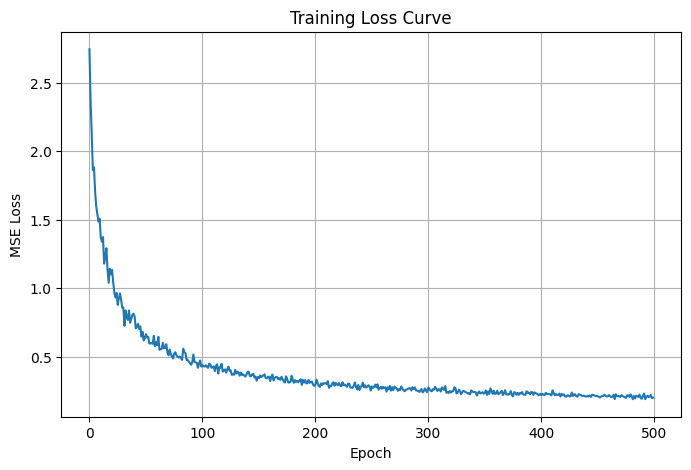

In [52]:
plt.figure(figsize=(8, 5))
plt.plot(loss_values)
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Training Loss Curve")
plt.grid(True)
plt.show()
